In [2]:
! pip install statsmodels

     ---------------------------------------- 9.6/9.6 MB 4.6 MB/s eta 0:00:00
     -------------------------------------- 233.3/233.3 kB 4.7 MB/s eta 0:00:00



[notice] A new release of pip available: 22.2.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
! pip install h2o

     -------------------------------------- 266.4/266.4 MB 2.7 MB/s eta 0:00:00



[notice] A new release of pip available: 22.2.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import numpy as np
import pandas as pd
import time

# plot
import matplotlib.pyplot as plt
import seaborn as sns

# statistics tools
from statsmodels.graphics.mosaicplot import mosaic

# ML
import h2o
from h2o.estimators import H2ORandomForestEstimator
from h2o.estimators import H2OGradientBoostingEstimator

In [6]:
df = pd.read_csv("data/healthcare-dataset-stroke-data.csv")

In [8]:
df.shape

(5110, 12)

In [9]:
print(df.columns.tolist())

['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [11]:
df.bmi = df.bmi.fillna(-99)

In [12]:
df.rename(columns = {'Residence_type':'residence_type'}, inplace = True)

In [13]:
df['target'] = df.stroke
df = df.drop(['stroke'], axis=1) 

In [14]:
features_num = ['age', 'avg_glucose_level','bmi']

In [15]:
df[features_num].describe(percentiles=[0.1,0.25,0.5,0.75,0.9])

,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,5110.000000
mean,43.226614,106.147677,23.862603
std,22.612647,45.283560,26.028009
min,0.080000,55.120000,-99.000000
10%,11.000000,65.789000,18.290000
25%,25.000000,77.245000,22.900000
50%,45.000000,91.885000,27.700000
75%,61.000000,114.090000,32.800000
90%,75.000000,192.181000,38.700000
max,82.000000,271.740000,97.600000


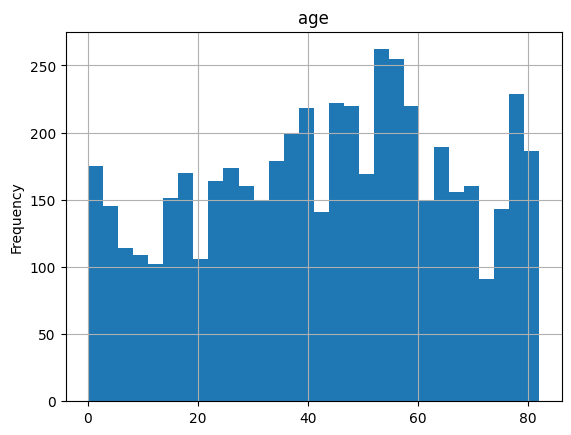

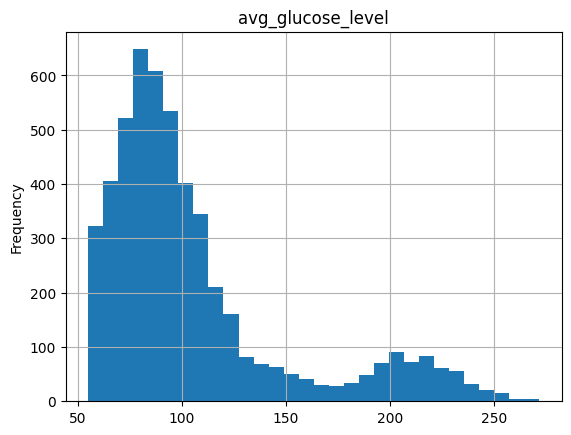

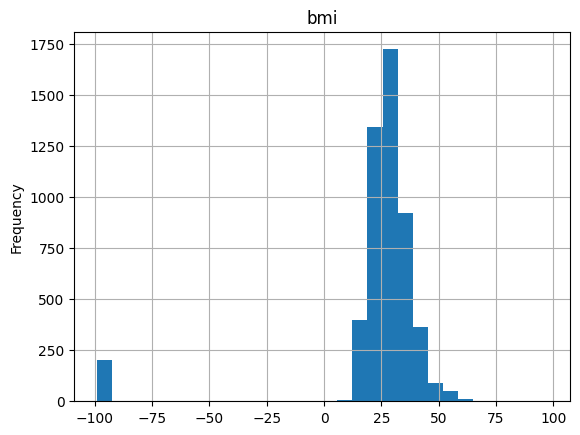

In [17]:
for f in features_num:
    df[f].plot(kind='hist', bins=30)
    plt.title(f)
    plt.grid()
    plt.show()

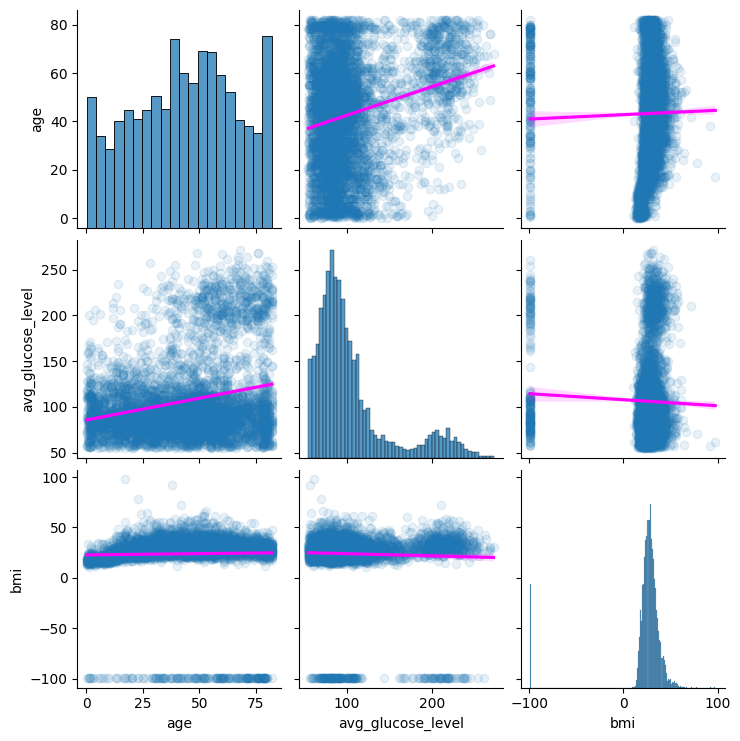

In [19]:
sns.pairplot(df[features_num], 
             kind='reg', 
             plot_kws={'line_kws':{'color':'magenta'}, 'scatter_kws': {'alpha': 0.1}})
plt.show()

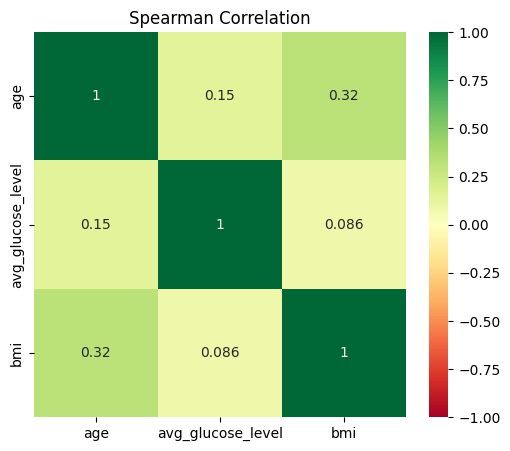

In [20]:
corr_spearman = df[features_num].corr(method='spearman')

fig = plt.figure(figsize = (6,5))
sns.heatmap(corr_spearman, annot=True, cmap="RdYlGn", vmin=-1, vmax=+1)
plt.title('Spearman Correlation')
plt.show()

In [22]:
features_cat = ['gender','hypertension','heart_disease','ever_married',
                'work_type','residence_type','smoking_status']

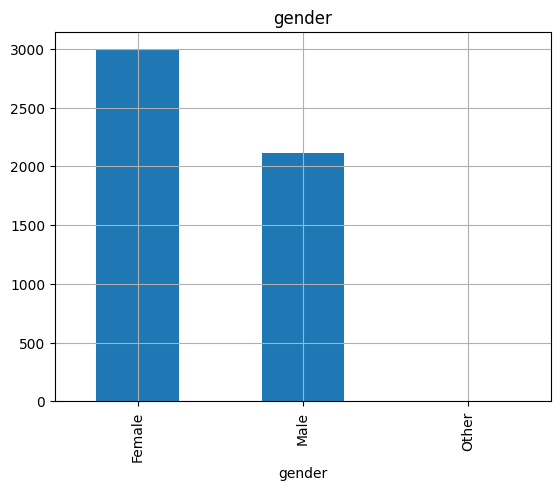

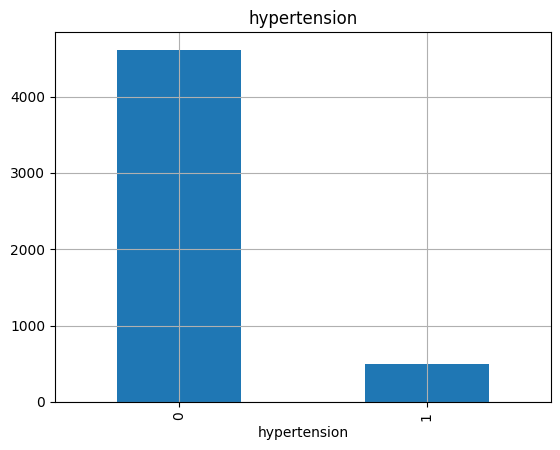

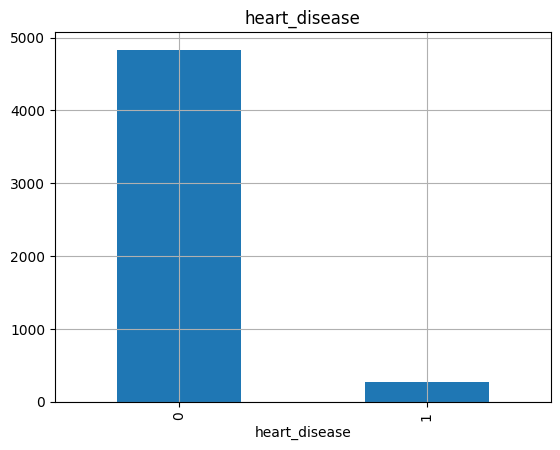

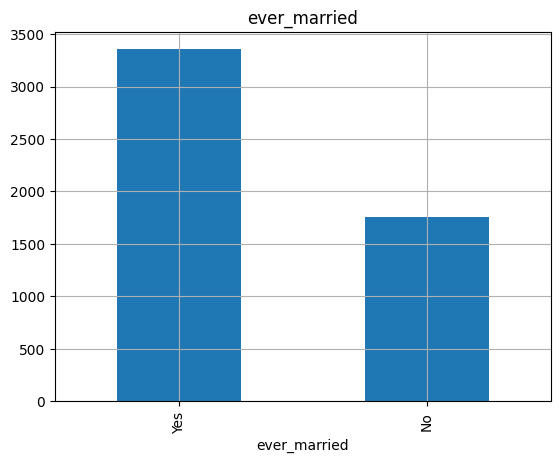

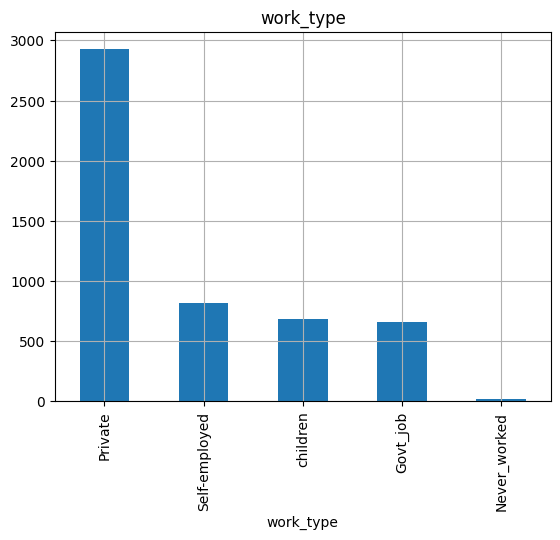

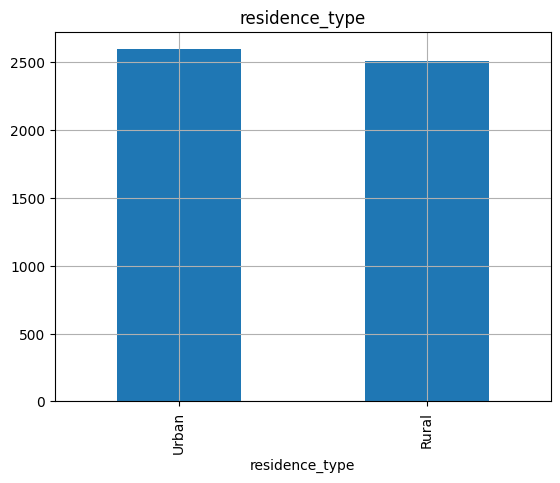

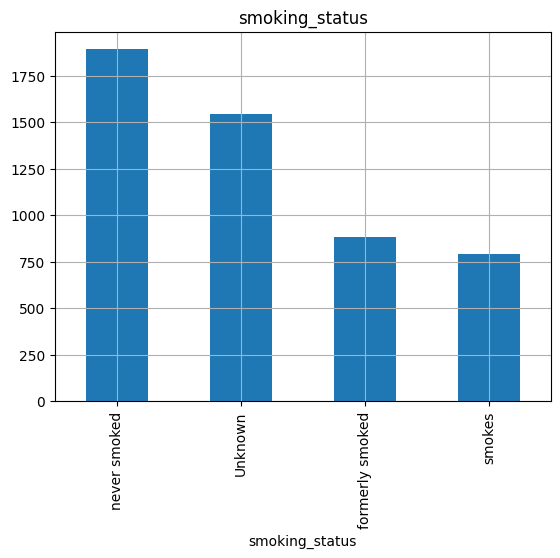

In [23]:
for f in features_cat:
    df[f].value_counts().plot(kind='bar')
    plt.title(f)
    plt.grid()
    plt.show()

In [24]:
target_count = df.target.value_counts()
print(target_count)
print()
print('Percentage of strokes [1]:', np.round(100*target_count[1] / target_count.sum(),2), '%')

target
0    4861
1     249
Name: count, dtype: int64

Percentage of strokes [1]: 4.87 %


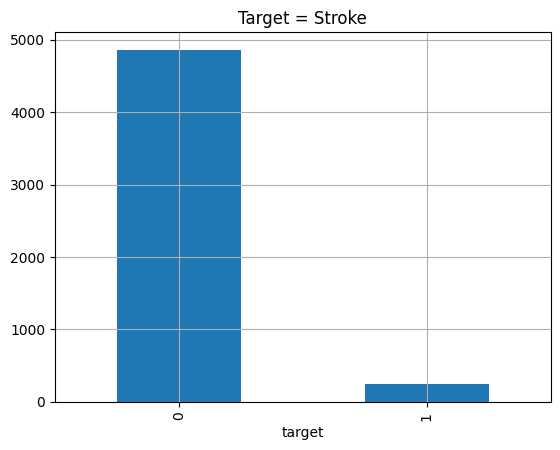

In [25]:
target_count.plot(kind='bar')
plt.title('Target = Stroke')
plt.grid()
plt.show()

In [26]:
df['age_bin'] = pd.qcut(df['age'], q=10, precision=1)
df['avg_glucose_level_bin'] = pd.qcut(df['avg_glucose_level'], q=10, precision=1)
df['bmi_bin'] = pd.cut(df['bmi'], [-100,10,20,25,30,35,40,50,100])

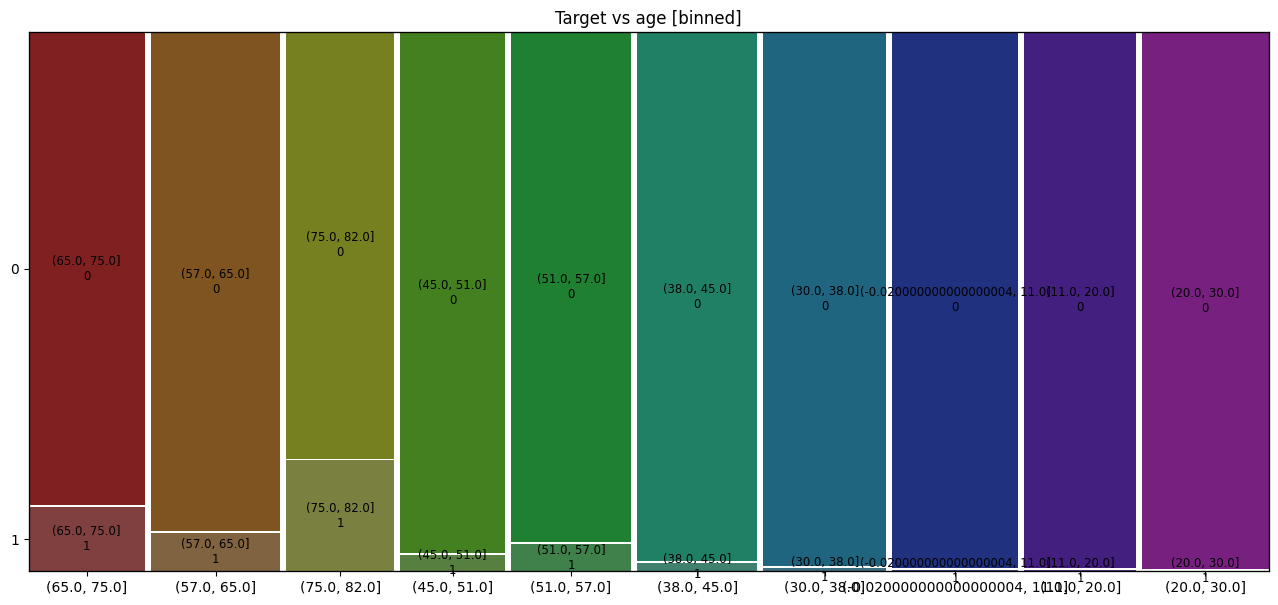

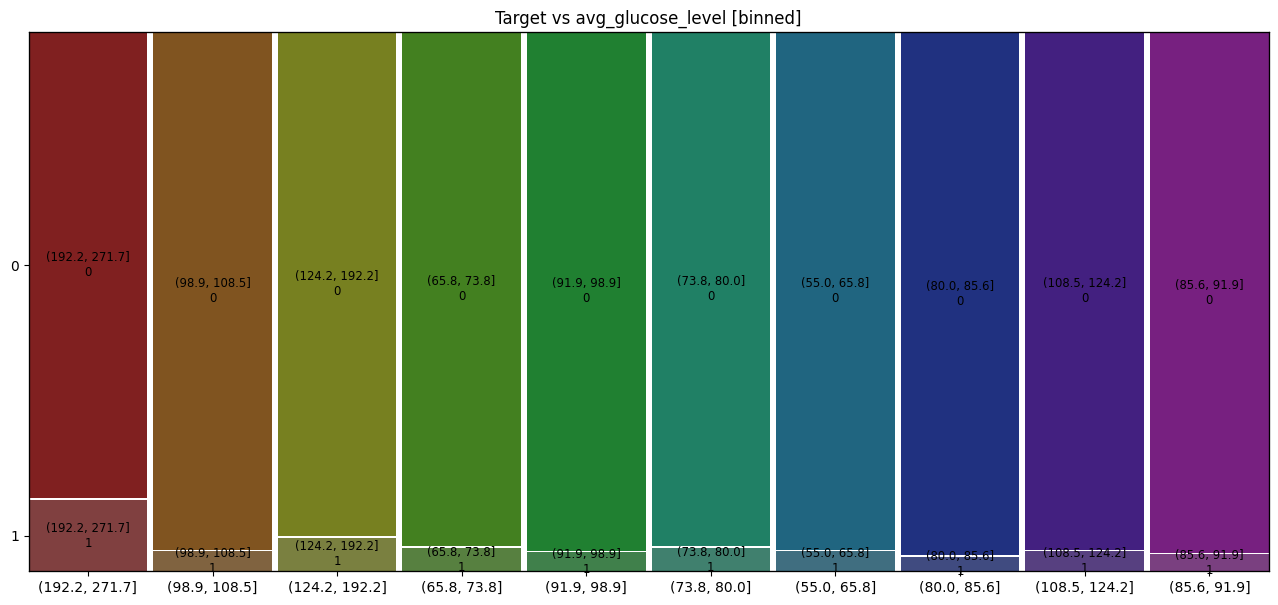

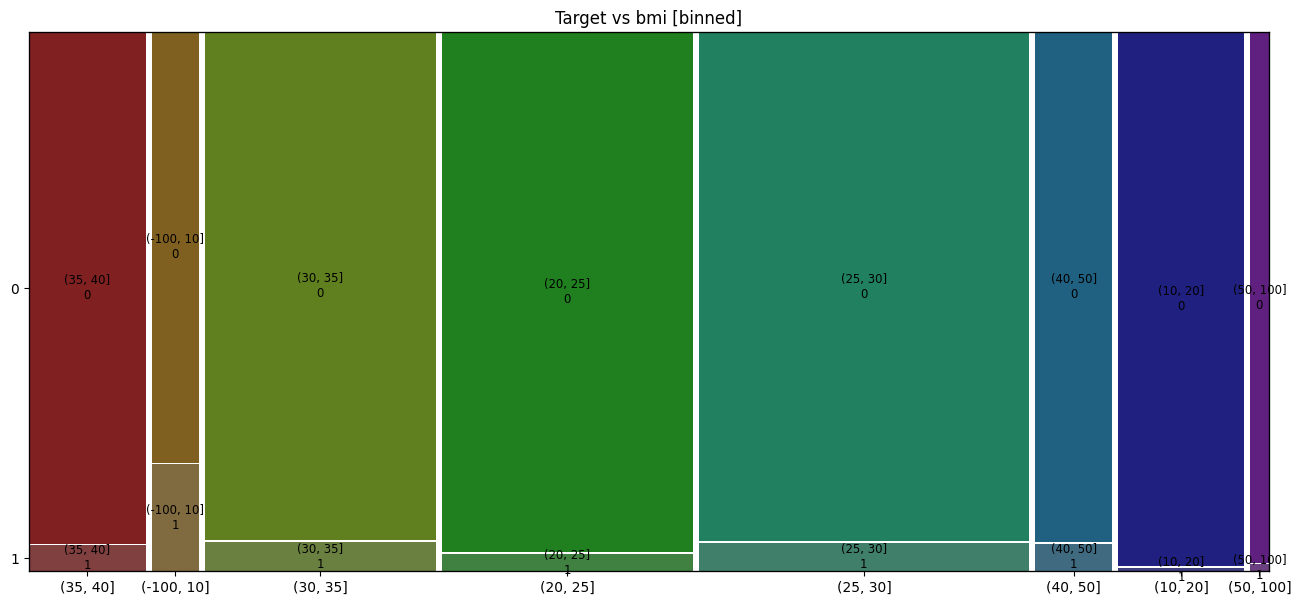

In [27]:
plt_para_save = plt.rcParams['figure.figsize'] # remember plot settings
for f in features_num:
    f_bin = f+'_bin'
    plt.rcParams["figure.figsize"] = (16,7) # increase plot size for mosaics
    mosaic(df, [f_bin, 'target'], title='Target vs ' + f + ' [binned]')
    plt.show()
plt.rcParams['figure.figsize'] = plt_para_save

In [28]:
ctab = pd.crosstab(df.bmi_bin, df.target)
ctab

target,0,1
bmi_bin,,
"(-100, 10]",161,40
"(10, 20]",534,3
"(20, 25]",1035,35
"(25, 30]",1334,75
"(30, 35]",931,54
"(35, 40]",476,24
"(40, 50]",312,17
"(50, 100]",78,1


In [29]:
(ctab.transpose() / ctab.sum(axis=1)).transpose()

target,0,1
bmi_bin,,
"(-100, 10]",0.800995,0.199005
"(10, 20]",0.994413,0.005587
"(20, 25]",0.967290,0.032710
"(25, 30]",0.946771,0.053229
"(30, 35]",0.945178,0.054822
"(35, 40]",0.952000,0.048000
"(40, 50]",0.948328,0.051672
"(50, 100]",0.987342,0.012658


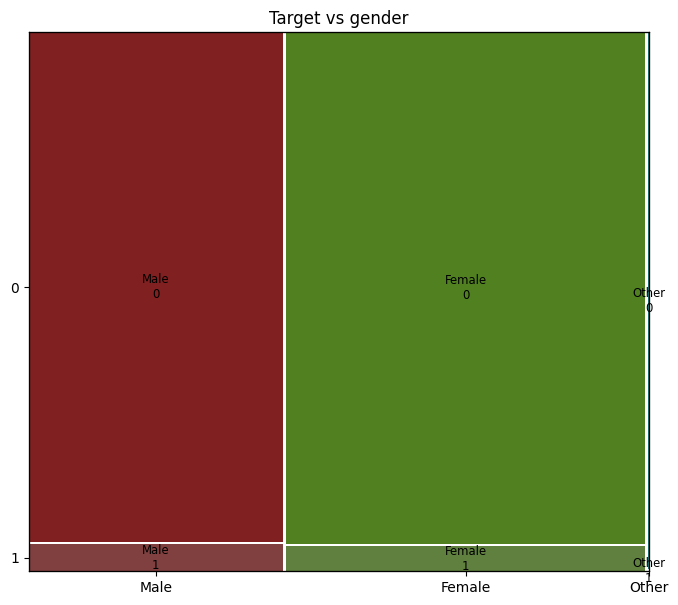

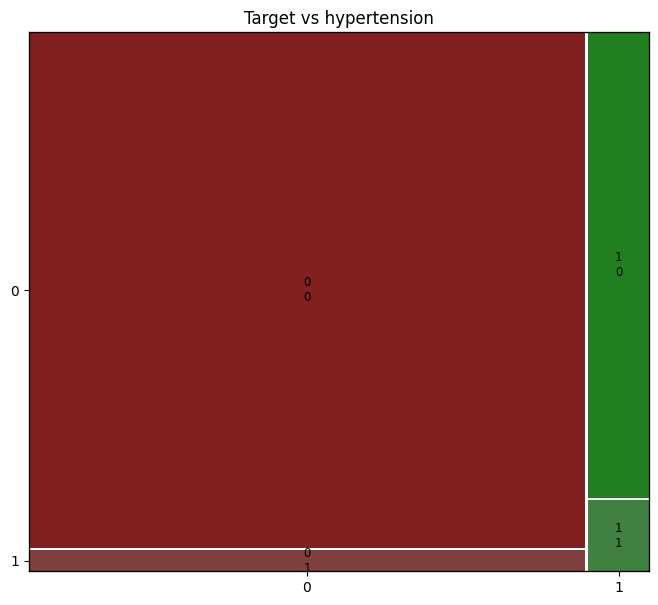

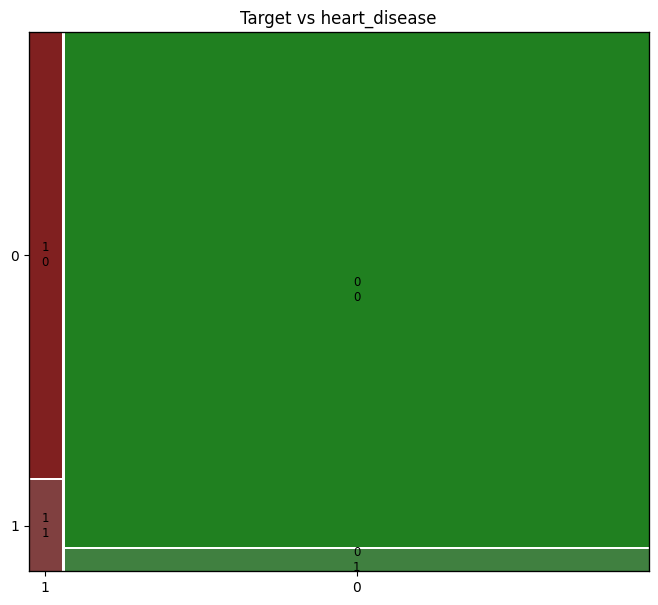

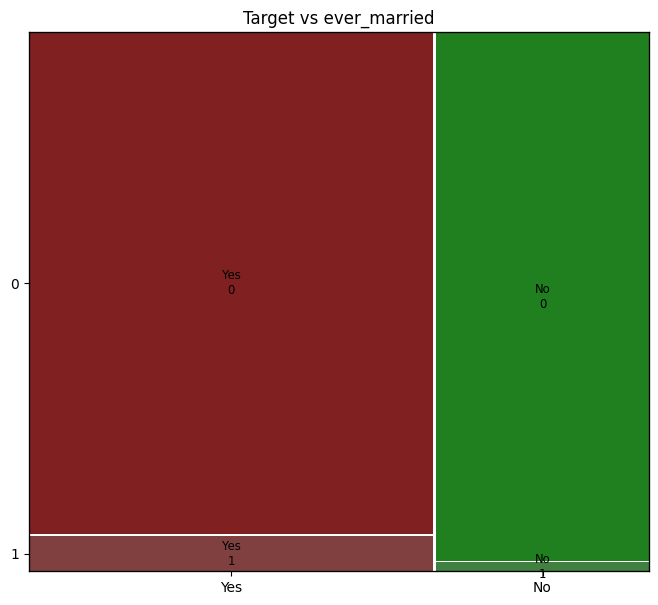

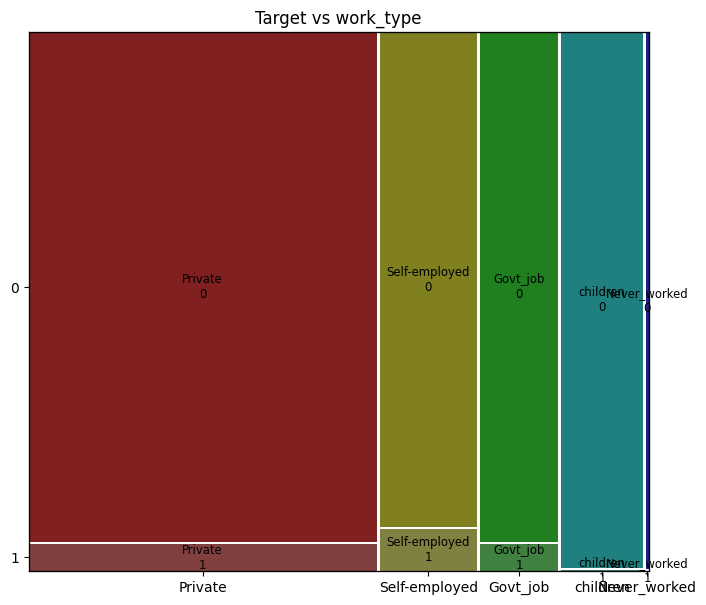

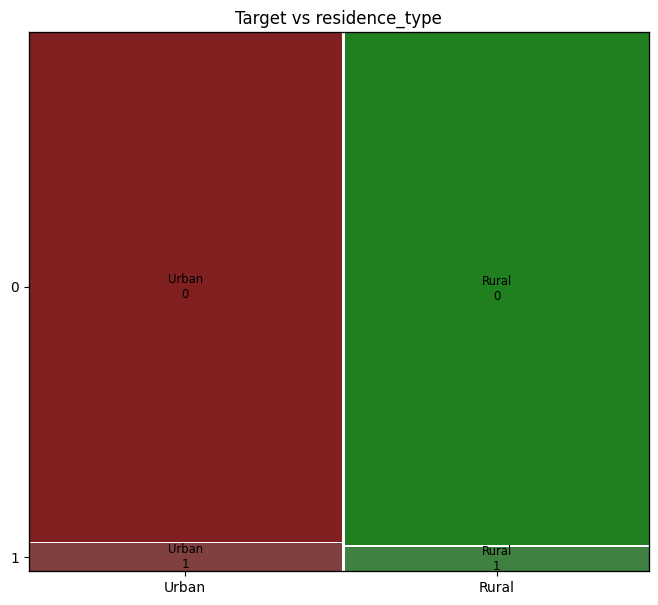

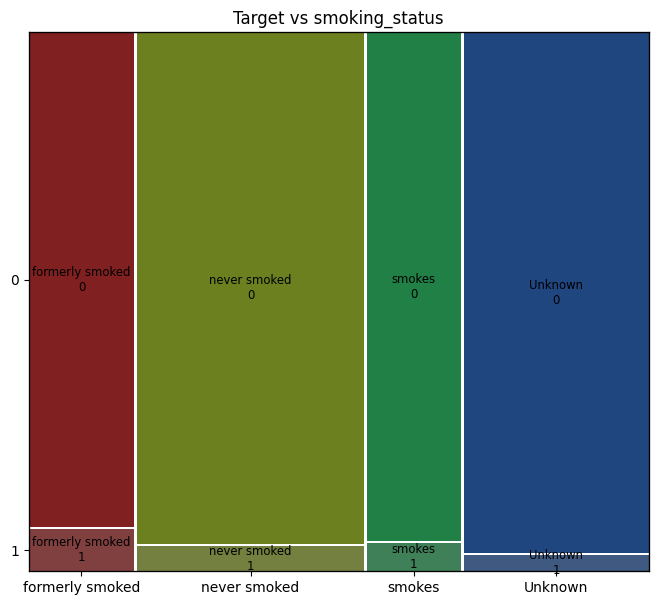

In [30]:
# plot target vs features using mosaic plot
plt_para_save = plt.rcParams['figure.figsize'] # remember plot settings

for f in features_cat:
    plt.rcParams["figure.figsize"] = (8,7) # increase plot size for mosaics
    mosaic(df, [f, 'target'], title='Target vs ' + f)
    plt.show()
    
# reset plot size again
plt.rcParams['figure.figsize'] = plt_para_save

In [31]:
ctab = pd.crosstab(df.ever_married, df.target)
ctab

target,0,1
ever_married,,
No,1728,29
Yes,3133,220


In [32]:
(ctab.transpose() / ctab.sum(axis=1)).transpose()

target,0,1
ever_married,,
No,0.983495,0.016505
Yes,0.934387,0.065613


In [33]:
predictors = features_num + features_cat
print('Number of predictors: ', len(predictors))
print(predictors)

Number of predictors:  10
['age', 'avg_glucose_level', 'bmi', 'gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'smoking_status']


In [34]:
h2o.init(max_mem_size='12G', nthreads=4) # Use maximum of 12 GB RAM and 4 cores

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; OpenJDK 64-Bit Server VM Temurin-21.0.8+9 (build 21.0.8+9-LTS, mixed mode, sharing)
  Starting server from C:\Users\roshn\OneDrive\Desktop\Nest\venv\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\roshn\AppData\Local\Temp\tmpqwzi5wmh
  JVM stdout: C:\Users\roshn\AppData\Local\Temp\tmpqwzi5wmh\h2o_roshn_started_from_python.out
  JVM stderr: C:\Users\roshn\AppData\Local\Temp\tmpqwzi5wmh\h2o_roshn_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,07 secs
H2O_cluster_timezone:,Asia/Kolkata
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,22 days
H2O_cluster_name:,H2O_from_python_roshn_r0z1dw
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,11.98 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,4
H2O_cluster_status:,"locked, healthy"


In [37]:
import warnings
warnings.filterwarnings("ignore")
# upload data frame in H2O environment
df_hex = h2o.H2OFrame(df)

# convert target to categorical
df_hex['target'] = df_hex['target'].asfactor()

# train / test split (70/30)
train_hex, test_hex = df_hex.split_frame(ratios=[0.7], seed=999)

# pandas versions of train/test
df_train = train_hex.as_data_frame()
df_test = test_hex.as_data_frame()


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [38]:
# export for potential external processing
df_train.to_csv('df_train.csv')
df_test.to_csv('df_test.csv')

In [40]:
# define Gradient Boosting model
fit_1 = H2OGradientBoostingEstimator(ntrees = 100,
                                     max_depth=4,
                                     min_rows=10,
                                     learn_rate=0.01, # default: 0.1
                                     sample_rate=1,
                                     col_sample_rate=0.7,
                                     nfolds=5,
                                     score_each_iteration=True,
                                     stopping_metric='auto',
                                     stopping_rounds=10,
                                     seed=999)

In [44]:
# train model
t1 = time.time()
fit_1.train(x=predictors,
            y='target',
            training_frame=train_hex)
t2 = time.time()
print('Elapsed time [s]: ', np.round(t2-t1,2))

gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%
Elapsed time [s]:  10.39


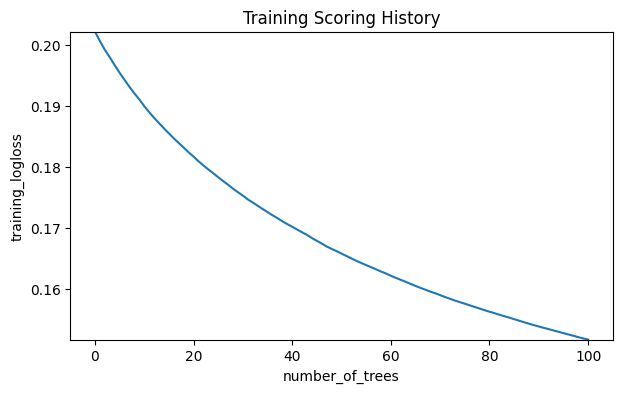

In [45]:
# show training scoring history
plt.rcParams['figure.figsize']=(7,4)
fit_1.plot()

In [46]:
# show cross validation metrics
fit_1.cross_validation_metrics_summary()

,mean,sd,cv_1_valid,cv_2_valid,cv_3_valid,cv_4_valid,cv_5_valid
accuracy,0.8829624,0.0268930,0.8985314,0.8645418,0.920904,0.8767313,0.8541033
aic,nan,0.0,nan,nan,nan,nan,nan
auc,0.8447821,0.0157750,0.8248061,0.8530365,0.8665343,0.8413103,0.8382235
err,0.1170376,0.0268930,0.1014686,0.1354582,0.0790960,0.1232687,0.1458967
err_count,83.8,18.308468,76.0,102.0,56.0,89.0,96.0
f0point5,0.2743523,0.0479990,0.2827381,0.2469136,0.3546099,0.2375,0.25
f1,0.3386312,0.0453714,0.3333333,0.32,0.4166667,0.2992126,0.3239437
f2,0.4459668,0.0421307,0.4059829,0.4545455,0.5050505,0.4042553,0.46
lift_top_group,8.911059,4.9263487,14.04375,4.9539475,10.411765,12.534722,2.6111112
loglikelihood,nan,0.0,nan,nan,nan,nan,nan


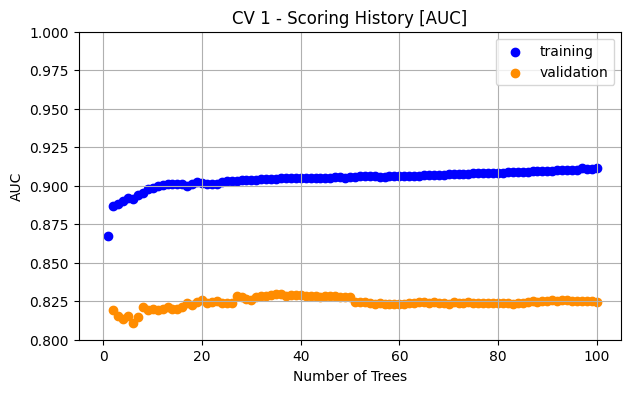

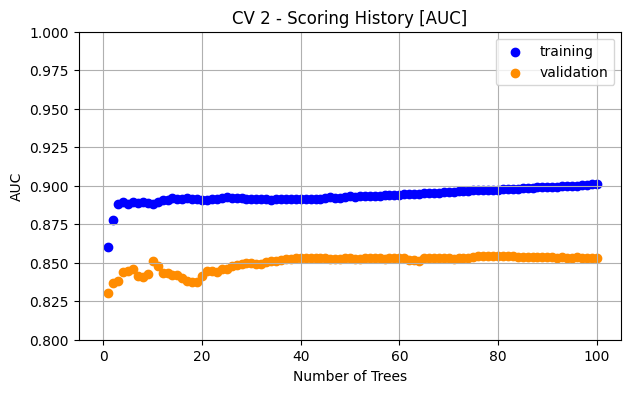

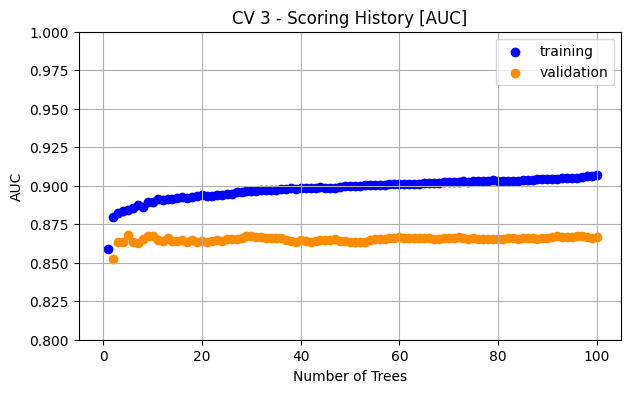

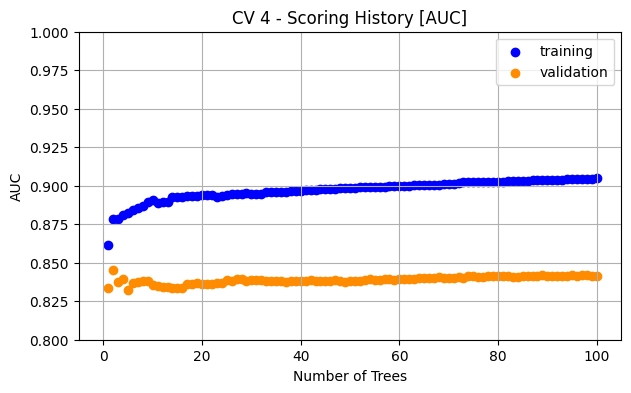

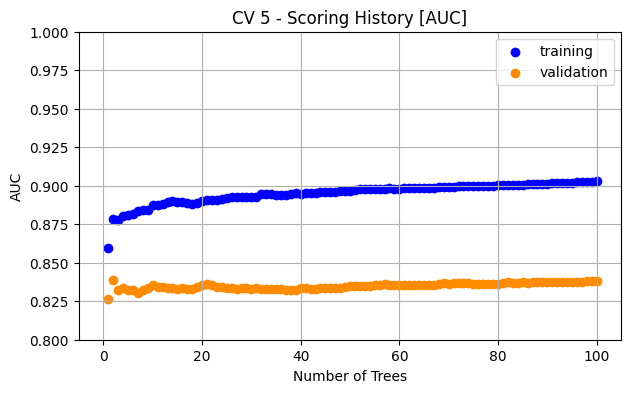

In [47]:
# show scoring history - training vs cross validations
for i in range(5):
    cv_model_temp = fit_1.cross_validation_models()[i]
    df_cv_score_history = cv_model_temp.score_history()
    my_title = 'CV ' + str(1+i) + ' - Scoring History [AUC]'
    plt.scatter(df_cv_score_history.number_of_trees,
                y=df_cv_score_history.training_auc, 
                c='blue', label='training')
    plt.scatter(df_cv_score_history.number_of_trees,
                y=df_cv_score_history.validation_auc, 
                c='darkorange', label='validation')
    plt.title(my_title)
    plt.xlabel('Number of Trees')
    plt.ylabel('AUC')
    plt.ylim(0.8,1)
    plt.legend()
    plt.grid()
    plt.show()

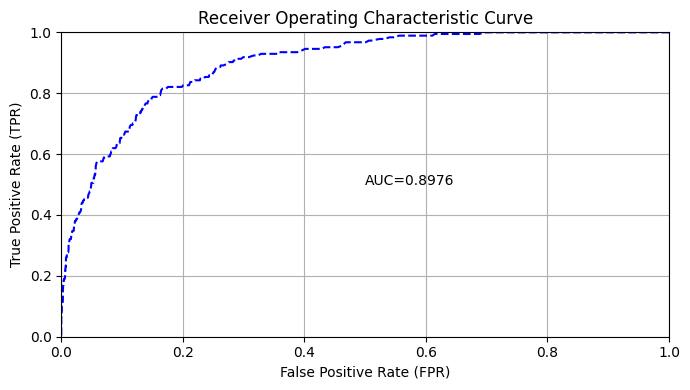

([0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0002935995302407516,
  0.0002935995302407516,
  0.0005871990604815032,
  0.0005871990604815032,
  0.0005871990604815032,
  0.0005871990604815032,
  0.0008807985907222549,
  0.0008807985907222549,
  0.0008807985907222549,
  0.0008807985907222549,
  0.0011743981209630064,
  0.001467997651203758,
  0.001467997651203758,
  0.001467997651203758,
  0.0017615971814445098,
  0.002055196711685261,
  0.002348796241926013,
  0.0026423957721667646,
  0.0026423957721667646,
  0.0026423957721667646,
  0.0026423957721667646,
  0.0026423957721667646,
  0.0026423957721667646,
  0.002935995302407516,
  0.002935995302407516,
  0.002935995302407516,
  0.0035231943628890195,
  0.0035231943628890195,
  0.0035231943628890195,
  0.003816793893129771,
  0.003816793893129771,
  0.004110393423370522,
  0.004697592483852026,
  0.0049911920140927775,
  0.005578391074574281,
  0.005871990604815032,
  0.0064591896652965355,
  0.00645918

In [48]:
# training performance
perf_train = fit_1.model_performance(train=True)
perf_train.plot()

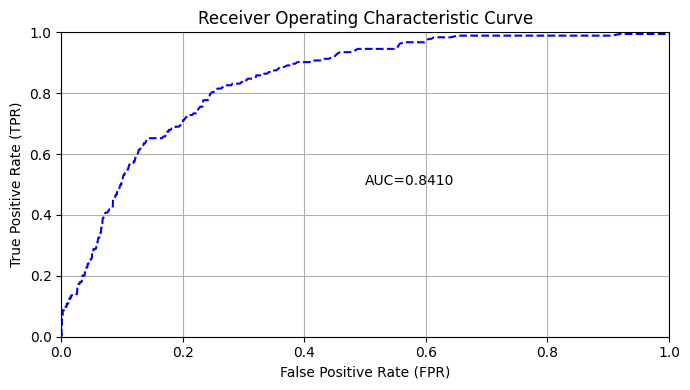

([0.0002935995302407516,
  0.0002935995302407516,
  0.0005871990604815032,
  0.0005871990604815032,
  0.0005871990604815032,
  0.0005871990604815032,
  0.0005871990604815032,
  0.0005871990604815032,
  0.0005871990604815032,
  0.0005871990604815032,
  0.0008807985907222549,
  0.0008807985907222549,
  0.0008807985907222549,
  0.0011743981209630064,
  0.0011743981209630064,
  0.0011743981209630064,
  0.001467997651203758,
  0.0017615971814445098,
  0.0017615971814445098,
  0.002055196711685261,
  0.002055196711685261,
  0.002348796241926013,
  0.002348796241926013,
  0.002348796241926013,
  0.002935995302407516,
  0.0032295948326482677,
  0.0035231943628890195,
  0.003816793893129771,
  0.004403992953611274,
  0.004697592483852026,
  0.0049911920140927775,
  0.005284791544333529,
  0.005578391074574281,
  0.005871990604815032,
  0.006165590135055784,
  0.006165590135055784,
  0.006752789195537287,
  0.006752789195537287,
  0.007339988256018791,
  0.007633587786259542,
  0.008220786846741

In [49]:
# cross validation performance
perf_cv = fit_1.model_performance(xval=True)
perf_cv.plot()

In [50]:
# on training data - automatic threshold (optimal F1 score)
conf_train = fit_1.confusion_matrix(train=True)
conf_train.show()

,0,1,Error,Rate
0,3209.0,197.0,0.0578,(197.0/3406.0)
1,79.0,105.0,0.4293,(79.0/184.0)
Total,3288.0,302.0,0.0769,(276.0/3590.0)


In [51]:
# corresponding accuracy for this threshold:
conf_list_temp = conf_train.to_list()
n_matrix = sum(conf_list_temp[0]) + sum(conf_list_temp[1])
acc_t0 = (conf_list_temp[0][0]+conf_list_temp[1][1]) / n_matrix
print('Accuracy:', np.round(acc_t0,6))

Accuracy: 0.92312


In [52]:
# alternatively specify threshold manually - here we try to achieve a symmetric outcome
tt = 0.148
conf_train_man = fit_1.confusion_matrix(train=True, thresholds=tt)
conf_train_man.show()

Could not find exact threshold 0.148; using closest threshold found 0.1478570244997902.


,0,1,Error,Rate
0,3297.0,109.0,0.032,(109.0/3406.0)
1,108.0,76.0,0.587,(108.0/184.0)
Total,3405.0,185.0,0.0604,(217.0/3590.0)


In [53]:
# corresponding accuracy for manual threshold:
conf_list_temp = conf_train_man.to_list()
n_matrix = sum(conf_list_temp[0]) + sum(conf_list_temp[1]) 
acc_t1 = (conf_list_temp[0][0]+conf_list_temp[1][1]) / n_matrix
print('Accuracy:', np.round(acc_t1,6))

Accuracy: 0.939554


In [54]:
# check on cross validation
conf_cv_man = fit_1.confusion_matrix(xval=True, thresholds=tt)
conf_cv_man.show()

Could not find exact threshold 0.148; using closest threshold found 0.14772756583508664.


,0,1,Error,Rate
0,3266.0,140.0,0.0411,(140.0/3406.0)
1,143.0,41.0,0.7772,(143.0/184.0)
Total,3409.0,181.0,0.0788,(283.0/3590.0)


In [55]:
# corresponding accuracy for our manual threshold:
conf_list_temp = conf_cv_man.to_list()
n_matrix = sum(conf_list_temp[0]) + sum(conf_list_temp[1])
acc_t1_CV = (conf_list_temp[0][0]+conf_list_temp[1][1]) / n_matrix
print('Accuracy:', np.round(acc_t1_CV,6))

Accuracy: 0.92117


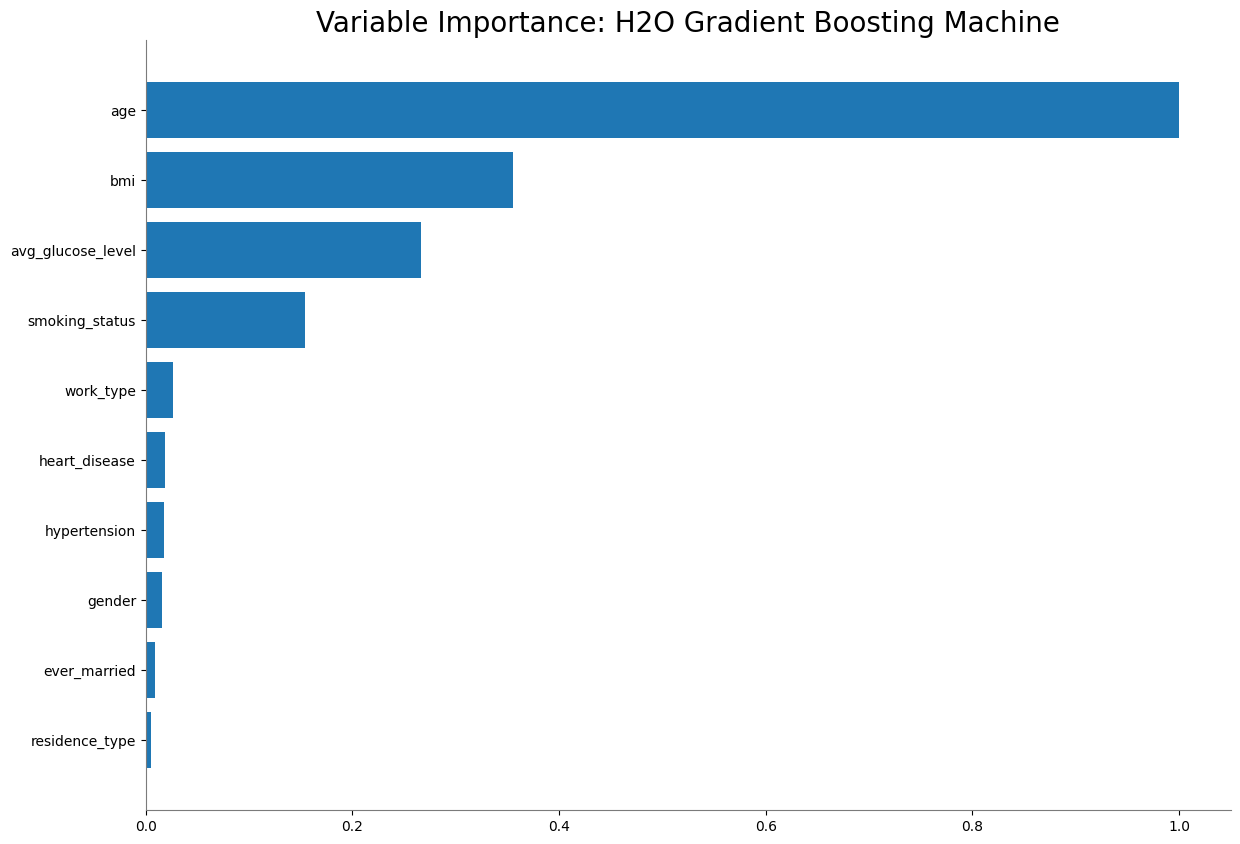

<Figure size 700x400 with 0 Axes>

In [56]:
# basic version
fit_1.varimp_plot()

In [63]:
! pip install shap

     -------------------------------------- 547.0/547.0 kB 1.3 MB/s eta 0:00:00
     ---------------------------------------- 78.6/78.6 kB 4.6 MB/s eta 0:00:00
     ---------------------------------------- 2.7/2.7 MB 2.9 MB/s eta 0:00:00
     ---------------------------------------- 38.1/38.1 MB 4.6 MB/s eta 0:00:00



[notice] A new release of pip available: 22.2.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


contributions progress: |████████████████████████████████████████████████████████| (done) 100%


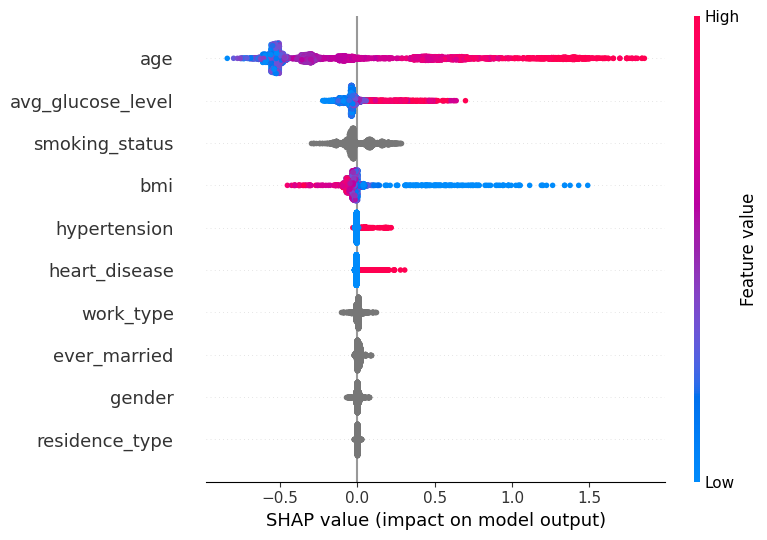

Elapsed time [s]:  2.72


In [64]:
import shap

# variable importance using shap values => see direction as well as severity of feature impact
t1 = time.time()

# 1. Get raw SHAP contributions from H2O
contributions = fit_1.predict_contributions(train_hex).as_data_frame()
# 2. Separate the SHAP values from the base value (BiasTerm)
shap_values = contributions.drop(columns=['BiasTerm']).values
# 3. Convert original features to pandas to match alignment
X_train = train_hex[list(contributions.columns[:-1])].as_data_frame()

# 4. Generate the exact same summary plot structure natively
shap.summary_plot(shap_values, X_train)

t2 = time.time()
print('Elapsed time [s]: ', np.round(t2-t1,2))

gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


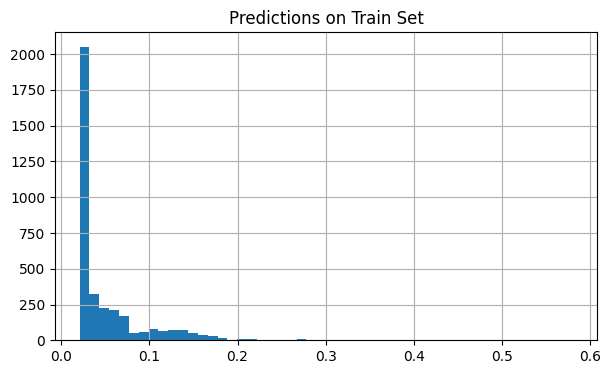

In [65]:
# predict on train set (extract probabilities only)
pred_train = fit_1.predict(train_hex)['p1']
pred_train = pred_train.as_data_frame().p1

# and plot
plt.hist(pred_train, bins=50)
plt.title('Predictions on Train Set')
plt.grid()
plt.show()

In [66]:
# check calibration
frequency_pred = sum(pred_train)
frequency_act = df_train.target.sum()
print('Predicted Frequency:', frequency_pred)
print('Actual Frequency   :', frequency_act)

Predicted Frequency: 184.40023228358385
Actual Frequency   : 184


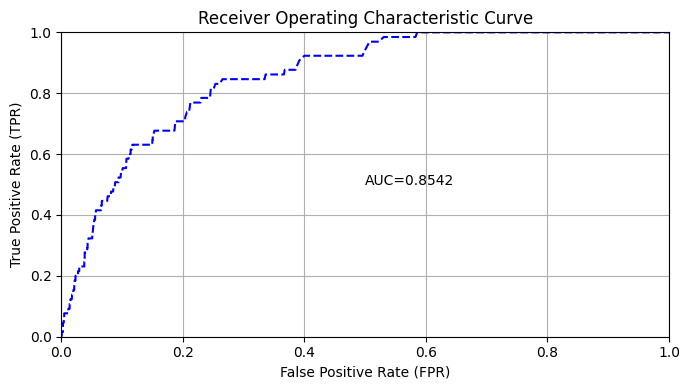

([0.0006872852233676976,
  0.0006872852233676976,
  0.0013745704467353953,
  0.002061855670103093,
  0.0027491408934707906,
  0.0027491408934707906,
  0.0027491408934707906,
  0.003436426116838488,
  0.004123711340206186,
  0.004123711340206186,
  0.004810996563573883,
  0.004810996563573883,
  0.005498281786941581,
  0.006185567010309278,
  0.006872852233676976,
  0.007560137457044674,
  0.008247422680412371,
  0.008934707903780068,
  0.010309278350515464,
  0.010996563573883162,
  0.01168384879725086,
  0.01168384879725086,
  0.012371134020618556,
  0.013058419243986255,
  0.013745704467353952,
  0.013745704467353952,
  0.01443298969072165,
  0.015120274914089347,
  0.015807560137457044,
  0.016494845360824743,
  0.01718213058419244,
  0.017869415807560136,
  0.019243986254295534,
  0.01993127147766323,
  0.021305841924398626,
  0.021305841924398626,
  0.021993127147766325,
  0.02268041237113402,
  0.02336769759450172,
  0.02336769759450172,
  0.024054982817869417,
  0.02474226804123

In [67]:
# calc performance on test test
perf_test = fit_1.model_performance(test_hex)

# ROC Curve - Test Set
perf_test.plot()

In [68]:
# confusion matrix using our manual threshold
conf_test_man = perf_test.confusion_matrix(thresholds=tt)
conf_test_man.show()

Could not find exact threshold 0.148; using closest threshold found 0.1480016916497603.


,0,1,Error,Rate
0,1401.0,54.0,0.0371,(54.0/1455.0)
1,50.0,15.0,0.7692,(50.0/65.0)
Total,1451.0,69.0,0.0684,(104.0/1520.0)


In [69]:
# calc accuracy for manual threshold:
conf_list_temp = conf_test_man.to_list()
n_matrix = sum(conf_list_temp[0]) + sum(conf_list_temp[1]) 
acc_t1_test = (conf_list_temp[0][0]+conf_list_temp[1][1]) / n_matrix
print('Accuracy:', np.round(acc_t1_test,6))

Accuracy: 0.931579


gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


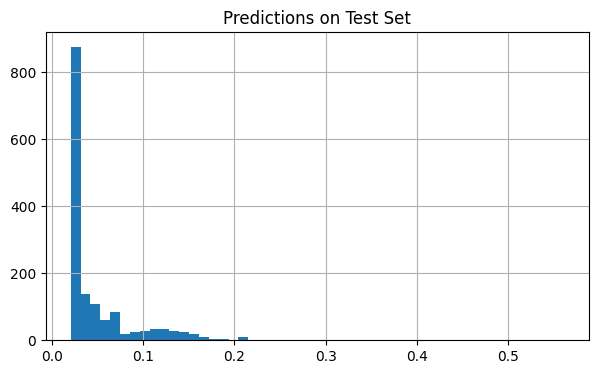

In [70]:
# predict on test set (extract probabilities only)
pred_test = fit_1.predict(test_hex)['p1']
pred_test = pred_test.as_data_frame().p1

# and plot
plt.hist(pred_test, bins=50)
plt.title('Predictions on Test Set')
plt.grid()
plt.show()

In [71]:
# connect prediction with data frame
df_test['prediction'] = pred_test

In [72]:
# show most endangered patients (according to our model) in test set
df_high_20 = df_test.nlargest(20, columns='prediction')
df_high_20

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,target,age_bin,avg_glucose_level_bin,bmi_bin,prediction
475,17752,Male,76.0,0,1,Yes,Private,Urban,79.05,-99.0,Unknown,0,"(75.0, 82.0]","(73.8, 80.0]","(-100, 10]",0.561063
21,7356,Male,75.0,0,0,Yes,Private,Urban,104.72,-99.0,Unknown,1,"(65.0, 75.0]","(98.9, 108.5]","(-100, 10]",0.550400
553,1741,Male,77.0,0,0,Yes,Private,Urban,74.26,-99.0,formerly smoked,0,"(75.0, 82.0]","(73.8, 80.0]","(-100, 10]",0.545057
380,132,Female,80.0,0,0,Yes,Govt_job,Urban,84.86,-99.0,Unknown,0,"(75.0, 82.0]","(80.0, 85.6]","(-100, 10]",0.531739
686,1077,Male,77.0,0,1,Yes,Govt_job,Rural,106.03,-99.0,Unknown,0,"(75.0, 82.0]","(98.9, 108.5]","(-100, 10]",0.520791
14,15102,Male,78.0,1,0,Yes,Private,Urban,75.32,-99.0,formerly smoked,1,"(75.0, 82.0]","(73.8, 80.0]","(-100, 10]",0.517326
4,8213,Male,78.0,0,1,Yes,Private,Urban,219.84,-99.0,Unknown,1,"(75.0, 82.0]","(192.2, 271.7]","(-100, 10]",0.305811
1483,10995,Male,76.0,1,0,Yes,Private,Rural,267.60,30.5,never smoked,0,"(75.0, 82.0]","(192.2, 271.7]","(30, 35]",0.305160
92,4480,Male,76.0,0,0,Yes,Private,Rural,234.58,34.3,formerly smoked,0,"(75.0, 82.0]","(192.2, 271.7]","(30, 35]",0.285260
6,25226,Male,57.0,0,1,No,Govt_job,Urban,217.08,-99.0,Unknown,1,"(51.0, 57.0]","(192.2, 271.7]","(-100, 10]",0.280943


In [73]:
print('Actual cases in highest 20    :', df_high_20.target.sum())
print('Predicted cases in highest 20 :', np.round(df_high_20.prediction.sum(),2))

Actual cases in highest 20    : 5
Predicted cases in highest 20 : 6.69


In [74]:
# show least endangered patients (according to our model) in test set
df_low_20 = df_test.nsmallest(20, columns='prediction')
df_low_20

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,target,age_bin,avg_glucose_level_bin,bmi_bin,prediction
788,57904,Male,15.0,0,0,No,Private,Urban,190.13,20.7,never smoked,0,"(11.0, 20.0]","(124.2, 192.2]","(20, 25]",0.020934
67,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,Unknown,0,"(11.0, 20.0]","(124.2, 192.2]","(10, 20]",0.020988
83,55680,Male,13.0,0,0,No,children,Urban,114.84,18.3,Unknown,0,"(11.0, 20.0]","(108.5, 124.2]","(10, 20]",0.020988
98,42996,Female,36.0,0,0,No,Govt_job,Rural,126.82,23.3,never smoked,0,"(30.0, 38.0]","(124.2, 192.2]","(20, 25]",0.020988
118,56681,Female,22.0,0,0,No,Private,Urban,130.34,22.0,never smoked,0,"(20.0, 30.0]","(124.2, 192.2]","(20, 25]",0.020988
125,34376,Female,16.0,0,0,No,children,Rural,113.47,19.5,Unknown,0,"(11.0, 20.0]","(108.5, 124.2]","(10, 20]",0.020988
143,22622,Male,10.0,0,0,No,children,Rural,108.79,21.0,Unknown,0,"(-0.020000000000000004, 11.0]","(108.5, 124.2]","(20, 25]",0.020988
161,61408,Male,23.0,0,0,No,Never_worked,Urban,125.26,18.7,never smoked,0,"(20.0, 30.0]","(124.2, 192.2]","(10, 20]",0.020988
175,20364,Female,4.0,0,0,No,children,Urban,107.25,12.0,Unknown,0,"(-0.020000000000000004, 11.0]","(98.9, 108.5]","(10, 20]",0.020988
254,32554,Female,16.0,0,0,No,children,Rural,109.02,19.8,Unknown,0,"(11.0, 20.0]","(108.5, 124.2]","(10, 20]",0.020988


In [75]:
print('Actual cases in lowest 20    :', df_low_20.target.sum())
print('Predicted cases in lowest 20 :', np.round(df_low_20.prediction.sum(),2))

Actual cases in lowest 20    : 0
Predicted cases in lowest 20 : 0.42
